In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Loading the massive dataset.... this might take a few seconds.")
df_fraud = pd.read_csv('creditcard.csv')

Loading the massive dataset.... this might take a few seconds.


In [6]:
# Check size and missing value
print(f"Total Rows: {df_fraud.shape[0]}")
print(f"Total Columns: {df_fraud.shape[1]}")
print("Missing Values:", df_fraud.isnull().sum().max()) # Should be 0

Total Rows: 284807
Total Columns: 31
Missing Values: 0


In [9]:
#  Check Class Imbalabnce
print("\nClass Distribution (0 = Normal, 1 = Fraud):")
class_counts = df_fraud['Class'].value_counts(normalize=True) * 100
print(class_counts)


Class Distribution (0 = Normal, 1 = Fraud):
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


C:\Users\vivek\AppData\Local\Temp\ipykernel_25776\2292450516.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Class', data=df_fraud, palette='Set1')


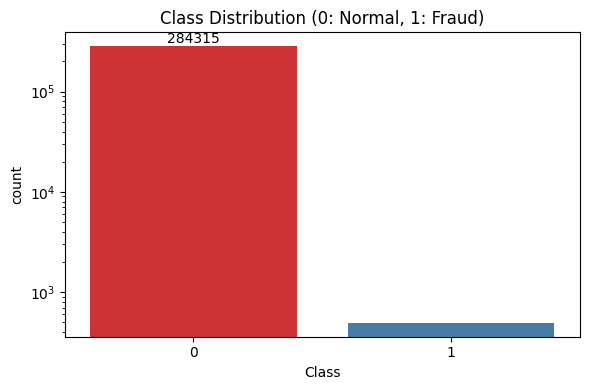

In [15]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='Class', data=df_fraud, palette='Set1')
plt.title('Class Distribution (0: Normal, 1: Fraud)')
plt.yscale('log')
ax.bar_label(ax.containers[0])
plt.tight_layout()
plt.show()

Building the Isolation Forest Model... (Please wait ~1-2 minutes)

--- Isolation Forest Results ---
Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    284315
       Fraud       0.31      0.30      0.31       492

    accuracy                           1.00    284807
   macro avg       0.65      0.65      0.65    284807
weighted avg       1.00      1.00      1.00    284807



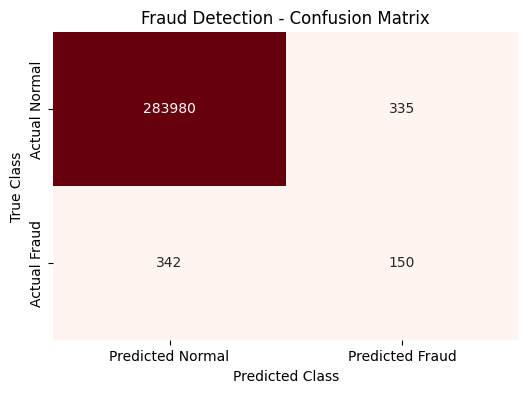

In [16]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Separate the features and the target
X = df_fraud.drop('Class', axis=1)
y = df_fraud['Class']

# Initialize the Isolation Forest Model
print("Building the Isolation Forest Model... (Please wait ~1-2 minutes)")
iso_forest = IsolationForest(n_estimators=100, max_samples=len(X), contamination=0.0017, random_state=42)

iso_forest.fit(X)
predictions = iso_forest.predict(X)

# Isolation Forest outputs: 1 for Normal, -1 for Anomaly (Fraud)
# We map it to: 0 for Normal, 1 for Fraud so it matches 'y' target
predictions_mapped = [1 if p == -1 else 0 for p in predictions]

print("\n--- Isolation Forest Results ---")
print("Classification Report:")
print(classification_report(y, predictions_mapped, target_names=['Normal', 'Fraud']))

plt.figure(figsize=(6,4))
cm = confusion_matrix(y, predictions_mapped)
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds", cbar=False,
            xticklabels=['Predicted Normal', 'Predicted Fraud'],
            yticklabels=['Actual Normal', 'Actual Fraud'])
plt.title('Fraud Detection - Confusion Matrix')
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.show()

In [19]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler

# Scale the data so Logistic Regression doesn't struggle with big numbers
print("Scaling the features...")

# Initialize the StandardScaler object 
# (This prepares the tool that will standardize features by removing the mean and scaling to unit variance)
scaler = StandardScaler()

# Compute the mean and standard deviation for 'X' (fit) and then apply the scaling to 'X' (transform)
# The result is saved into a new variable, 'X_scaled'
X_scaled = scaler.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# Apply SMOTE
print("Applying SMOTE to balance the training data... (Please wait)")
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Train Models on the balanced, scaled data
print("Training Logistic Regression on balanced data...")
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_smote, y_train_smote)

print("Training Random Forest on balanced data... (This might take 1-3 minutes!)")
rf_model = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train_smote, y_train_smote)

# Evaluate Models
print("\n--- Logistic Regression (with SMOTE & Scaling) Results ---")
log_preds = log_model.predict(X_test)
print(classification_report(y_test, log_preds, target_names=['Normal', 'Fraud']))

print("\n--- Random Forest (with SMOTE & Scaling) Results ---")
rf_preds = rf_model.predict(X_test)
print(classification_report(y_test, rf_preds, target_names=['Normal', 'Fraud']))

Scaling the features...
Applying SMOTE to balance the training data... (Please wait)
Training Logistic Regression on balanced data...
Training Random Forest on balanced data... (This might take 1-3 minutes!)

--- Logistic Regression (with SMOTE & Scaling) Results ---
              precision    recall  f1-score   support

      Normal       1.00      0.97      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962


--- Random Forest (with SMOTE & Scaling) Results ---
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.43      0.86      0.57        98

    accuracy                           1.00     56962
   macro avg       0.71      0.93      0.79     56962
weighted avg       1.00      1.00      1.00     56962

